<a href="https://colab.research.google.com/github/prometricas/Yonny_Markov/blob/main/Yonny_tree_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. PREPARACIÓN Y ANÁLISIS DE DATOS**
Proyecto: Valoración para Opción Real


In [ ]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuro el estilo de mis gráficas para que se vean profesionales en el documento
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# CARGA DE DATOS
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Pigs/Yonny_Markov/Modelos/data_gas_carbón.xlsx'
df = pd.read_excel(path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,date,gas_price,carbon_price
0,1997-01-15,3.45,35.23
1,1997-02-15,2.15,34.60
2,1997-03-15,1.89,34.50
3,1997-04-15,2.03,35.40
4,1997-05-15,2.25,35.73


## **1.2. Distribución de frecuencias**
* Para modelar el Movimiento Browniano, necesito la volatilidad (sigma) y la deriva (mu).
* Estas no salen del precio bruto, sino de los rendimientos logarítmicos.
* Fórmula: r_t = ln( P_t / P_{t-1} )


--- Parámetros estimados para el Gas Natural (Mensual) ---
Tendencia promedio (Mu): -0.0004
Volatilidad histórica (Sigma): 0.1526


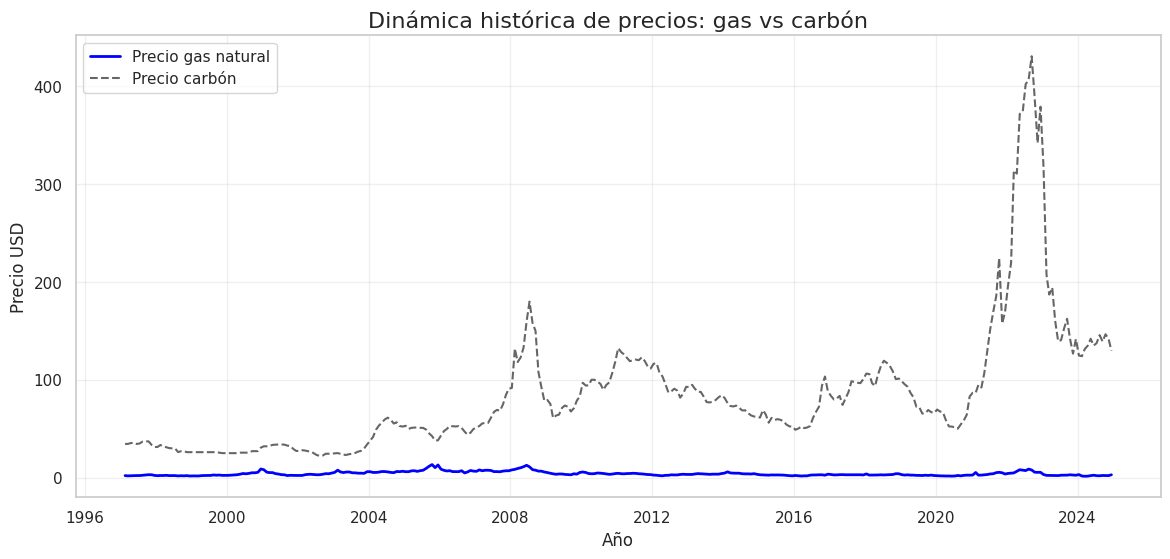

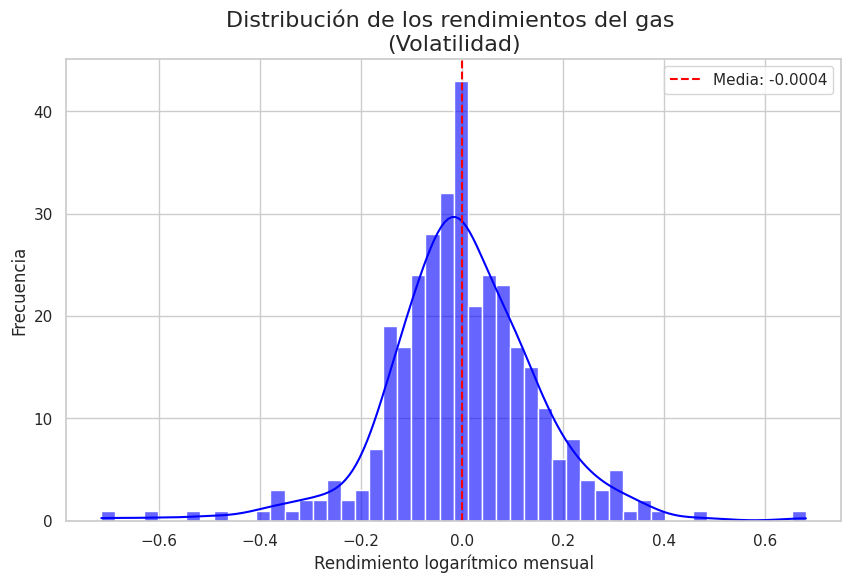

In [ ]:

# Calculo retornos para el Gas Natural
df['log_ret_gas'] = np.log(df['gas_price'] / df['gas_price'].shift(1))

# Calculo retornos para el Carbón (para efectos comparativos)
df['log_ret_carbon'] = np.log(df['carbon_price'] / df['carbon_price'].shift(1))

# Elimino la primera fila (NaN) ya que no tiene dato anterior para comparar
df = df.dropna()


# ------------------------------------------
# Aquí calculo mis parámetros clave para la simulación posterior.

# Promedio de rendimientos (Mu diario/mensual según mis datos)
mu_gas = df['log_ret_gas'].mean()
# Desviación estándar (Sigma - Volatilidad histórica)
sigma_gas = df['log_ret_gas'].std()

print("\n--- Parámetros estimados para el Gas Natural (Mensual) ---")
print(f"Tendencia promedio (Mu): {mu_gas:.4f}")
print(f"Volatilidad histórica (Sigma): {sigma_gas:.4f}")


# ------------------------------------------
# VISUALIZACIÓN DE LA HISTORIA (Mis Gráficas de soporte)
# Gráfica 1: Evolución de Precios Históricos
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['gas_price'], label='Precio gas natural', color='blue', linewidth=2)
plt.plot(df['date'], df['carbon_price'], label='Precio carbón', color='black', alpha=0.6, linestyle='--')
plt.title('Dinámica histórica de precios: gas vs carbón', fontsize=16)
plt.ylabel('Precio USD', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Comentario personal sobre la Gráfica 1:
# "Al graficar la historia, noto claramente que el gas tiene picos de volatilidad
# mucho más agresivos que el carbón, lo que justifica usar Opciones Reales
# para gestionar este riesgo."

# Gráfica 2: Distribución de los Rendimientos (Histograma)
plt.figure(figsize=(10, 6))
sns.histplot(df['log_ret_gas'], bins=50, kde=True, color='blue', alpha=0.6)
plt.title('Distribución de los rendimientos del gas \n(Volatilidad)', fontsize=16)
plt.xlabel('Rendimiento logarítmico mensual', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.axvline(x=mu_gas, color='red', linestyle='--', label=f'Media: {mu_gas:.4f}')
plt.legend()
plt.show()

# Comentario personal sobre la Gráfica 2:
# "Esta campana me permite validar si los retornos siguen una distribución normal,
# supuesto clave para aplicar el Movimiento Browniano Geométrico en el siguiente paso."

# **2. SIMULACIÓN DE ESCENARIOS MONTECARLO**
Esta sección  toma los parámetros que calculé en el Paso 1 ($\mu$ y $\sigma$) y los introduce en la ecuación del Movimiento Browniano Geométrico para proyectar 1000 futuros posibles.

# **2.1. Definición de los parámetros de simulación**

In [ ]:
S0 = df['gas_price'].iloc[-1]  # Precio inicial (el último dato real que tengo)
T_years = 10                   # Horizonte del proyecto (10 años es estándar en energía)
N_steps = T_years * 12         # Total de pasos (120 meses)
dt = 1                         # Delta de tiempo (1 mes, coincidiendo con mis datos)
n_sims = 1000                  # Número de iteraciones a simular (para robustez estadística)

print(f"--- Configuración de la Simulación ---")
print(f"Precio Inicial (S0): ${S0:.2f}")
print(f"Horizonte: {T_years} años ({N_steps} meses)")
print(f"Escenarios: {n_sims}")

--- Configuración de la Simulación ---
Precio Inicial (S0): $3.01
Horizonte: 10 años (120 meses)
Escenarios: 1000


## **2.2. Modelo browniano geométrico (GBM)**
* Aplico la ecuación estocástica: S_t = S_{t-1} * exp(...)
* Uso datos vectorizados (más rápido que un bucle for tradicional).


In [ ]:
# Genero los choques aleatorios (Z) para todos los pasos y simulaciones
# Z ~ Normal(0, 1)
np.random.seed(42) # Semilla para que mis resultados sean reproducibles en la sustentación
Z = np.random.normal(0, 1, (N_steps, n_sims))

# Calculo los componentes deterministas y estocásticos
# Drift: Tendencia ajustada por volatilidad
drift = (mu_gas - 0.5 * sigma_gas**2) * dt
# Difusión: El impacto de la volatilidad en cada paso
diffusion = sigma_gas * np.sqrt(dt)

# Matriz para guardar los precios (Filas=Tiempo, Columnas=Simulaciones)
simulated_paths = np.zeros((N_steps + 1, n_sims))
simulated_paths[0] = S0

# Itero paso a paso para construir las trayectorias
for t in range(1, N_steps + 1):
    # El precio de hoy depende del de ayer multiplicado por el cambio logarítmico
    shock = drift + diffusion * Z[t-1]
    simulated_paths[t] = simulated_paths[t-1] * np.exp(shock)


## **2.3. Visualización de resultados**
En esta gráfica evidencio que, aunque la media (línea roja) muestra una tendencia, la dispersión de los escenarios grises confirma el alto riesgo del proyecto.

Justamente esa 'nube' de incertidumbre es lo que el método de Opciones Reales captura mejor que un VPN tradicional estático.

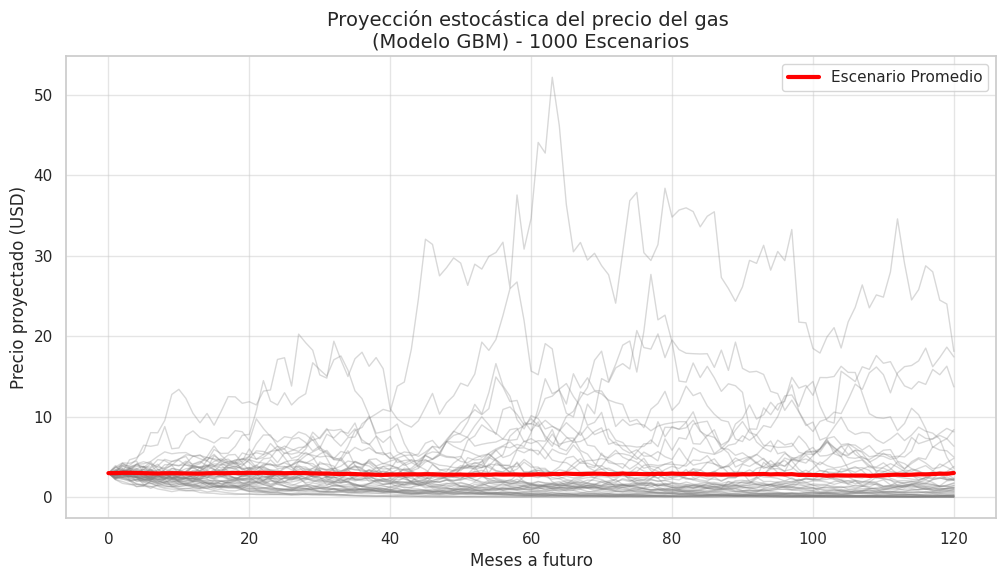

In [ ]:
# Trazo las primeras 50 trayectorias en gris para no saturar visualmente
plt.figure(figsize=(12, 6))
plt.plot(simulated_paths[:, :50], color='gray', alpha=0.3, linewidth=1)

# Trazo el promedio de todos los escenarios en rojo (Tendencia Esperada)
plt.plot(simulated_paths.mean(axis=1), color='red', linewidth=3, label='Escenario Promedio')

plt.title(f'Proyección estocástica del precio del gas \n(Modelo GBM) - {n_sims} Escenarios', fontsize=14)
plt.xlabel('Meses a futuro', fontsize=12)
plt.ylabel('Precio proyectado (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# **3. Cálculo de parámetros del árbol binomial.**
Este bloque cierra el ciclo lógico. Toma la volatilidad que descubrí en los datos históricos (Paso 1) y la convierte en los valores fundamentos ($u, d, p$) con los que construirás el árbol de valoración de Opciones Reales.

Defino las variables estructurales para mi árbol binomial.
* T: Horizonte de tiempo en años (mismo que en la simulación Browniana)
* N: Número de pasos del árbol. Para esta visualización usaré pocos pasos para que el gráfico sea legible, pero el modelo soporta N grandes.
* r: Tasa libre de riesgo. Uso un placeholder del 5% que debo validar con datos macro.

**Conclusión:** Con esta estructura de árbol ya calibrada con la volatilidad real, el siguiente paso será simplemente recorrer el árbol hacia atrás (Backward Induction) para calcular en qué nodos conviene ejercer la opción de abandono (respondiendo así a la crítica metodológica).



--- Parámetros Calibrados del Árbol Binomial ---
Volatilidad usada (Sigma): 15.26%
Factor de Subida (u): 1.2409 (El precio puede subir 24.09% por paso)
Factor de Bajada (d): 0.8059 (El precio puede bajar 19.41% por paso)
Probabilidad Neutra al Riesgo (p): 0.6880


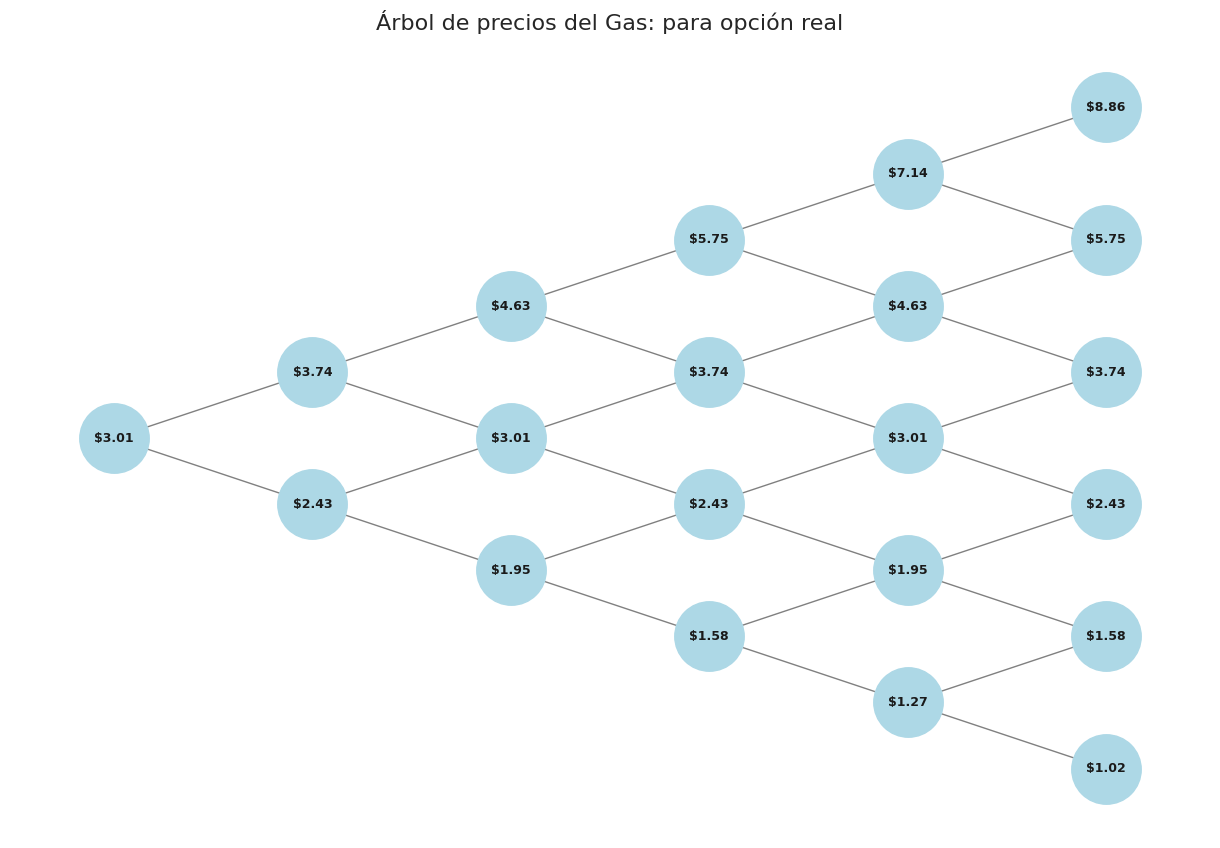

In [ ]:
import networkx as nx

# 1. DEFINICIÓN DE VARIABLES DEL ÁRBOL
# ------------------------------------------
T_tree = 10     # Horizonte del proyecto en años
N_tree = 5      # 5 pasos anuales para efectos de visualización clara hoy
dt_tree = T_tree / N_tree  # Tamaño del salto de tiempo (2 años en este ejemplo visual)
r = 0.05        # Tasa libre de riesgo (Supuesto temporal)

# 2. CÁLCULO DE FACTORES (Metodología Cox-Ross-Rubinstein)
# ------------------------------------------
# Calculo los movimientos de subida (u) y bajada (d) basados en la volatilidad histórica real
# (sigma_gas) que calculé en el Paso A. Esto es crucial: mis parámetros NO son inventados,
# vienen de la historia real del activo.

u = np.exp(sigma_gas * np.sqrt(dt_tree)) # Factor de subida
d = 1 / u                                # Factor de bajada
p_prob = (np.exp(r * dt_tree) - d) / (u - d) # Probabilidad neutra al riesgo

print(f"\n--- Parámetros Calibrados del Árbol Binomial ---")
print(f"Volatilidad usada (Sigma): {sigma_gas:.2%}")
print(f"Factor de Subida (u): {u:.4f} (El precio puede subir { (u-1):.2%} por paso)")
print(f"Factor de Bajada (d): {d:.4f} (El precio puede bajar { (1-d):.2%} por paso)")
print(f"Probabilidad Neutra al Riesgo (p): {p_prob:.4f}")

# 3. CONSTRUCCIÓN Y VISUALIZACIÓN DEL ÁRBOL
# ------------------------------------------
# Genero una gráfica de red (árbol) para mostrar explícitamente los posibles caminos de precio.

def binomial_tree_prices(S0, u, d, N):
    # Matriz para guardar los precios
    prices = np.zeros((N + 1, N + 1))
    prices[0, 0] = S0
    for i in range(1, N + 1):
        prices[i, 0] = prices[i - 1, 0] * u # Camino de puras subidas (borde superior)
        for j in range(1, i + 1):
            prices[i, j] = prices[i - 1, j - 1] * d # Bajada desde el nodo anterior
    return prices

# Calculo los precios teóricos
tree_prices = binomial_tree_prices(S0, u, d, N_tree)

# Uso NetworkX para dibujar la estructura
G = nx.Graph()
pos = {}
labels = {}

for i in range(N_tree + 1):
    for j in range(i + 1):
        node_name = f"{i},{j}"
        G.add_node(node_name)
        # Posición para que parezca un árbol acostado (Tiempo vs Precio)
        pos[node_name] = (i, -2 * j + i)
        labels[node_name] = f"${tree_prices[i, j]:.2f}"

        # Conecto con los padres (si no es el nodo inicial)
        if i > 0:
            if j < i: G.add_edge(f"{i-1},{j}", node_name)   # Viene de una subida
            if j > 0: G.add_edge(f"{i-1},{j-1}", node_name) # Viene de una bajada

plt.figure(figsize=(12, 8))
nx.draw(G, pos, labels=labels, with_labels=True, node_size=2500,
        node_color="lightblue", font_size=9, font_weight="bold", edge_color="gray")
plt.title(f"Árbol de precios del Gas: para opción real", fontsize=16)
plt.xlabel("Pasos de Tiempo", fontsize=12)
plt.show()